<a href="https://colab.research.google.com/github/MitaliKalburgi/python-assignment-part4/blob/main/part4_visualization_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Student Performance Analysis & Prediction**

In [43]:
# Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
"""

# Save file
with open("students.csv", "w") as f:
    f.write(data)

print("students.csv file created successfully!")

students.csv file created successfully!


**Task 1 - Data Exploration with Pandas**

In [44]:
# Load dataset
df = pd.read_csv("students.csv")

# 1. First 5 rows
print("First 5 rows:\n")
print(df.head())

First 5 rows:

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [45]:
# 2. Shape & Data Types
print("\nShape (rows, columns):", df.shape)
print("\nData Types:\n")
print(df.dtypes)


Shape (rows, columns): (15, 9)

Data Types:

name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [46]:
# 3. Summary Statistics
print("\nSummary Statistics:\n")
stats = df.describe().loc[["mean", "min", "max", "std"]]    # mean, min, max, std
print(stats)


Summary Statistics:

           math    science    english    history         pe  attendance_pct  \
mean  65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
min   30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
max   95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   
std   20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   

      study_hours_per_day    passed  
mean             2.893333  0.600000  
min              0.500000  0.000000  
max              6.000000  1.000000  
std              1.658944  0.507093  


In [47]:
# 4. Pass/Fail Count
print("\nPass/Fail Count:\n")
print(df["passed"].value_counts())


Pass/Fail Count:

passed
1    9
0    6
Name: count, dtype: int64


In [48]:
# 5. Average Scores (Pass vs Fail)
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage Scores (Passed Students):\n")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nAverage Scores (Failed Students):\n")
print(df[df['passed'] == 0][subject_cols].mean())


Average Scores (Passed Students):

math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average Scores (Failed Students):

math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [49]:
# 6. Top Student (Highest Average)
df["average_score"] = df[subject_cols].mean(axis=1)

top_student = df.loc[df["average_score"].idxmax()]

print("\nTop Student:\n")
print(top_student[["name", "average_score"]])


Top Student:

name             Diana
average_score     94.0
Name: 3, dtype: object


**Task 2 - Data Visualization with Matplotlib**

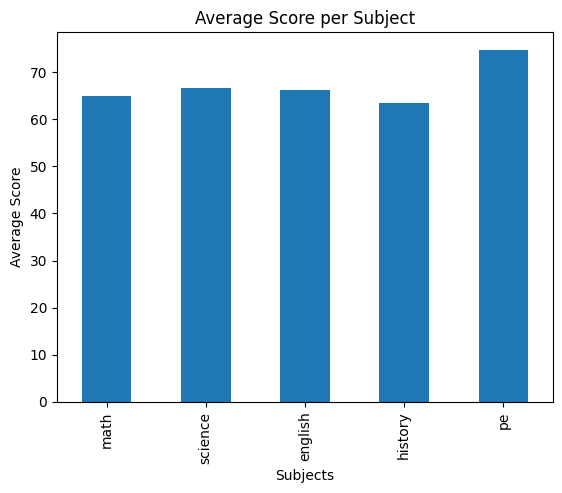

In [50]:
# Add avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


# 1. Bar Chart - Avg score per subject
avg_scores = df[subject_cols].mean()

plt.figure()
avg_scores.plot(kind='bar')

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()

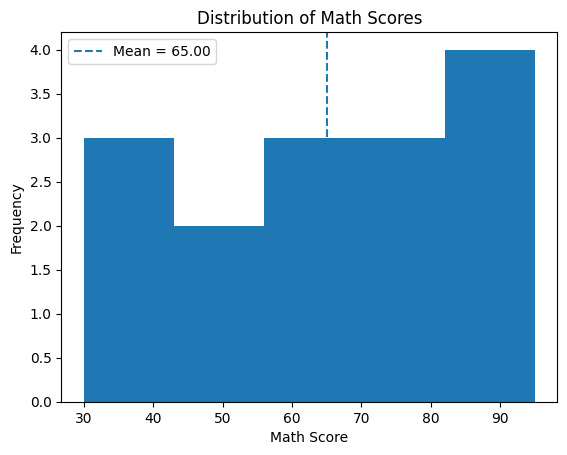

In [51]:
# 2. Histogram - Math scores
plt.figure()

plt.hist(df['math'], bins=5)

mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_histogram.png")
plt.show()

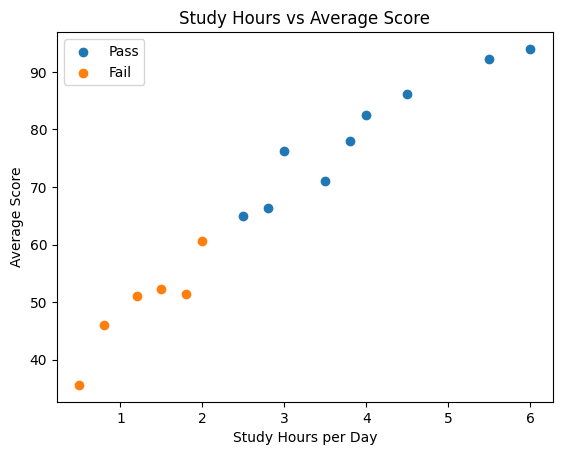

In [52]:
# 3. Scatter Plot - Study hours vs Avg score
plt.figure()

passed = df[df['passed'] == 1]
failed = df[df['passed'] == 0]

plt.scatter(passed['study_hours_per_day'], passed['avg_score'], label="Pass")
plt.scatter(failed['study_hours_per_day'], failed['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

/tmp/ipykernel_8255/2298008157.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


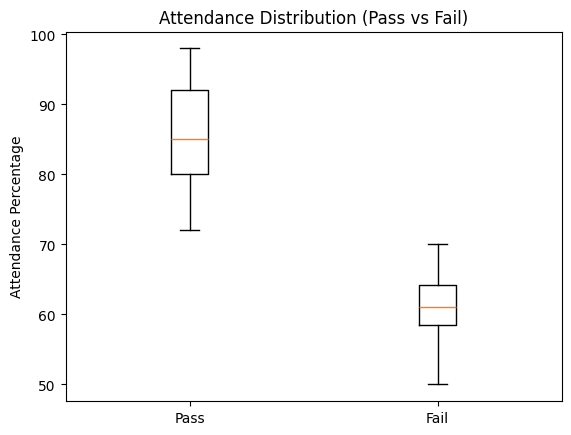

In [53]:
# 4. Box Plot - Attendance
plt.figure()

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution (Pass vs Fail)")
plt.ylabel("Attendance Percentage")

plt.savefig("plot4_boxplot.png")
plt.show()

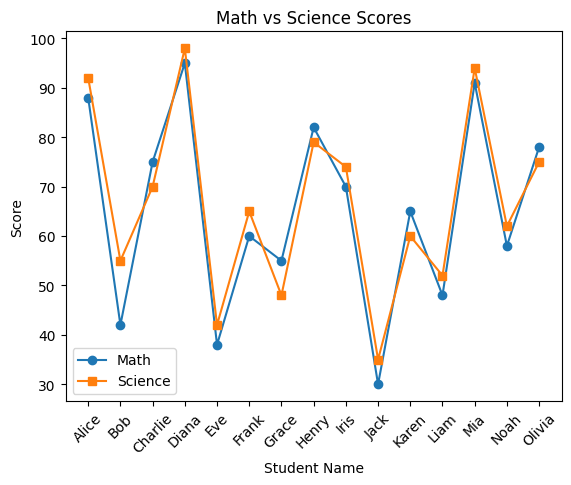

In [54]:
# 5. Line Plot - Math & Science
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label="Math")
plt.plot(df['name'], df['science'], marker='s', label="Science")

plt.title("Math vs Science Scores")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

**Task 3 - Data Visualization with Seaborn**

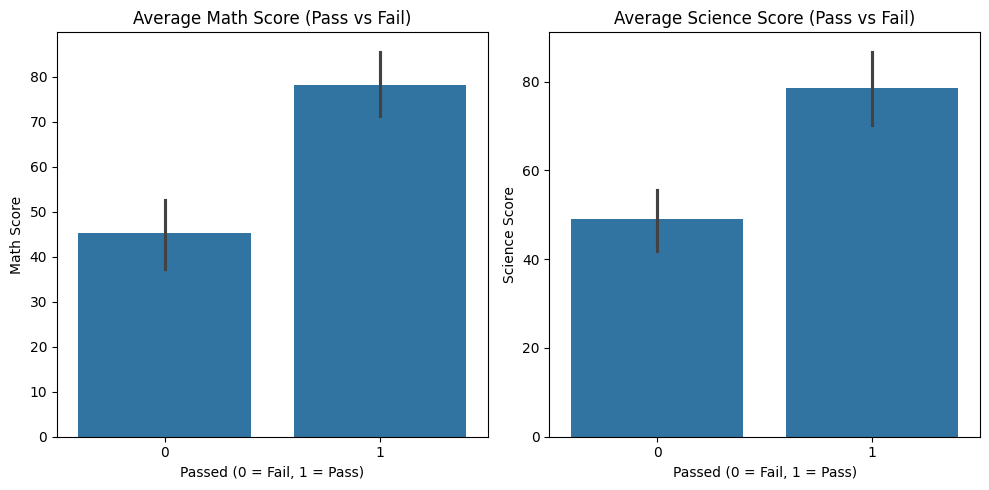

In [55]:
# 1. Bar Plot - Math & Science (Pass vs Fail)
plt.figure(figsize=(10, 5))

# Subplot 1 - Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Math Score")

# Subplot 2 - Science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

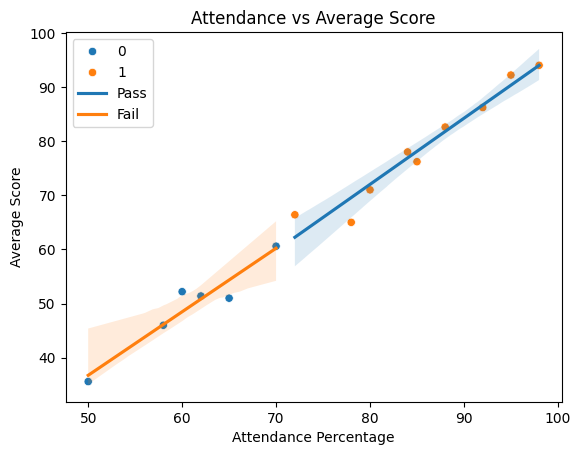

In [56]:
# 2. Scatter Plot with Regression
plt.figure()

# Scatter plot
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression lines (separate for Pass and Fail)
sns.regplot(data=df[df['passed']==1],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Pass')

sns.regplot(data=df[df['passed']==0],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Fail')

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [57]:
# 3. Comparison Comment
# Seaborn made plotting easier and more visually appealing with less code, especially for grouped data and adding colors automatically.
# Matplotlib required more manual setup (labels, legends, styling), while Seaborn handled many of these features by default.

**Task 4 - Machine Learning with scikit-learn**

In [58]:
# Step 1 - Prepare Data

# 1. Separate Features (X) and Target (y)
features = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']

X = df[features]   # DO NOT include 'name'
y = df['passed']

# 2. Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Scaling using StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)        # transform test

print("Data preparation complete")

Data preparation complete


In [59]:
# Step 2 - Train Model

# Create model
model = LogisticRegression()

# Train model on scaled data
model.fit(X_train_scaled, y_train)

# Training accuracy
train_accuracy = model.score(X_train_scaled, y_train)

print(f"Training Accuracy: {train_accuracy:.2f}")

Training Accuracy: 1.00


In [60]:
# Step 3 - Evaluate Model

# 1. Predict on test data
y_pred = model.predict(X_test_scaled)

# 2. Test accuracy
test_accuracy = model.score(X_test_scaled, y_test)

print(f"\nTest Accuracy: {test_accuracy:.2f}")

# 3. Detailed Results (with names)
print("\nTest Results:\n")

for i, idx in enumerate(X_test.index):
    name = df.loc[idx, 'name']
    actual = y_test.loc[idx]
    predicted = y_pred[i]

    if actual == predicted:
        result = "✅ Correct"
    else:
        result = "❌ Wrong"

    print(f"{name} → Actual: {actual}, Predicted: {predicted} → {result}")


Test Accuracy: 1.00

Test Results:

Jack → Actual: 0, Predicted: 0 → ✅ Correct
Liam → Actual: 0, Predicted: 0 → ✅ Correct
Alice → Actual: 1, Predicted: 1 → ✅ Correct



Feature Importance (sorted):

english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


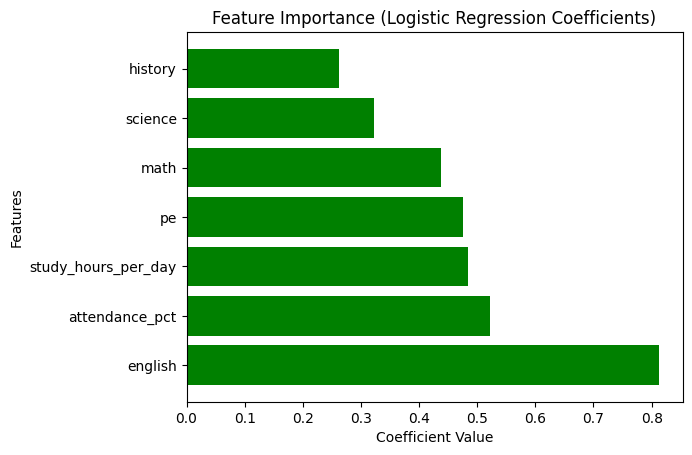

In [61]:
# Step 4 - Feature Importance

# 1. Get coefficients
coefficients = model.coef_[0]

# 2. Pair with feature names
feature_importance = list(zip(features, coefficients))

# Sort by absolute value (largest impact first)
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance (sorted):\n")
for feature, coef in feature_importance:
    print(f"{feature}: {coef:.4f}")


# 3. Bar Chart (Horizontal)
features_sorted = [f[0] for f in feature_importance]
coeffs_sorted = [f[1] for f in feature_importance]

# Color: green = positive, red = negative
colors = ['green' if c > 0 else 'red' for c in coeffs_sorted]

plt.figure()
plt.barh(features_sorted, coeffs_sorted, color=colors)

plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.savefig("plot8_feature_importance.png")
plt.show()

In [62]:
# Step 5 - New Student Prediction

# Define new student (same order as features)
new_student_df = pd.DataFrame([[75, 70, 68, 65, 80, 82, 3.2]], columns=features)

# Scale using SAME scaler
new_student_scaled = scaler.transform(new_student_df)

# Predict
prediction = model.predict(new_student_scaled)[0]

# Probability
probability = model.predict_proba(new_student_scaled)[0]

# Output
if prediction == 1:
    result = "Pass"
else:
    result = "Fail"

print("\nNew Student Prediction:")
print(f"Prediction: {result}")
print(f"Probability (Fail, Pass): {probability}")


New Student Prediction:
Prediction: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]
